# Taller 08 — Random Forest para clasificar dígitos escritos a mano

**Integrantes del grupo:**
- Iván Parra Rodelo
- Juan Bauz Villa
- Kevin Ruiz Espitia

## Objetivo

Diseñar e implementar clasificadores **Random Forest** para el dataset `digits` de scikit-learn y encontrar
**el mínimo número de árboles, del menor tamaño posible, que ofrezca los mejores indicadores de rendimiento sin generar over-fitting**.

Condiciones del taller:

- División del dataset: **80 % entrenamiento / 20 % prueba**.
- Entrenamiento con validación cruzada **K-fold, K = 4**.
- Explicar la estrategia usada para **podar o detener el crecimiento** de los árboles (parámetro `ccp_alpha`).

## Estrategia en resumen

1. Separar el 20 % de prueba y **no usarlo** hasta la evaluación final.
2. Medir dos líneas base (un árbol sin podar y un Random Forest por defecto) para conocer el over-fitting de partida.
3. Obtener los valores candidatos de `ccp_alpha` a partir de la **ruta de poda por costo-complejidad** (`cost_complexity_pruning_path`).
4. Para cada `ccp_alpha`, medir con K-fold = 4 la *accuracy* de entrenamiento y de validación de bosques de **1 a 200 árboles**.
5. Elegir primero el **tamaño de los árboles** (el `ccp_alpha` más grande cuyo desempeño no se distingue del mejor, *regla de 1 error estándar*) y luego el **número de árboles** (el menor número que alcanza la meseta de desempeño).
6. Comprobar que no hay over-fitting y evaluar **una sola vez** sobre el conjunto de prueba.

## 1. Librerías y configuración

In [2]:
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, ConfusionMatrixDisplay)

SEED = 42      # semilla para que todos los resultados sean reproducibles
K = 4          # número de folds de la validación cruzada
N_MAX = 200    # número máximo de árboles que se explora

# Estilo de las gráficas
AZUL, NARANJA, AQUA, AMARILLO, GRIS = '#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#8a8984'
AZULES = LinearSegmentedColormap.from_list('azules', ['#f4f8fe', '#9ec5f4', '#3987e5', '#1c5cab', '#0d366b'])
plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linewidth': 0.8, 'lines.linewidth': 2,
    'font.size': 10, 'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})


def fmt(df):
    # Redondea cada columna de una tabla según lo que representa (solo para mostrarla)
    dec = {'ccp_alpha': 5, 'nodos/árbol': 1, 'hojas/árbol': 1, 'profundidad': 1, 'nodos totales': 0}
    return df.round({c: dec.get(c, 4) for c in df.columns if pd.api.types.is_float_dtype(df[c])})


import sklearn

## 2. El dataset `digits`

Contiene 1 797 imágenes de 8×8 píxeles de dígitos del 0 al 9 escritos a mano. Cada imagen se representa como un vector de
**64 características**, una por píxel, con intensidades enteras entre 0 y 16. Las clases están prácticamente balanceadas (~180 imágenes por dígito).

Imágenes: 1797  |  Características por imagen: 64 (8×8 píxeles)  |  Clases: 10
Intensidad de los píxeles: de 0 a 16


,0,1,2,3,4,5,6,7,8,9
imágenes,178,182,177,183,181,182,181,179,174,180


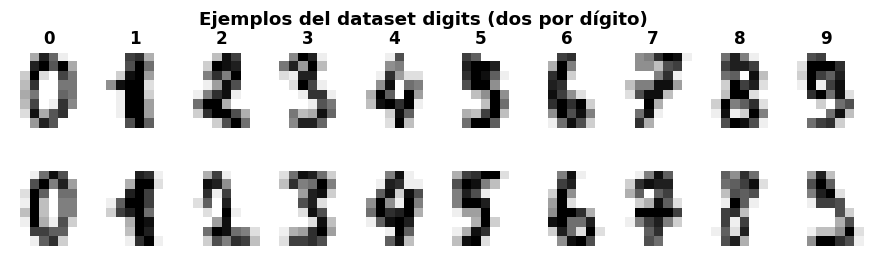

In [3]:
digits = load_digits()
X, y = digits.data, digits.target

print(f'Imágenes: {X.shape[0]}  |  Características por imagen: {X.shape[1]} (8×8 píxeles)  |  Clases: {len(np.unique(y))}')
print(f'Intensidad de los píxeles: de {X.min():.0f} a {X.max():.0f}')
display(pd.Series(y).value_counts().sort_index().rename('imágenes').to_frame().T)

# Dos ejemplos de cada dígito
fig, axes = plt.subplots(2, 10, figsize=(10, 2.6), gridspec_kw={'hspace': 0.15, 'wspace': 0.15})
for d in range(10):
    for fila, i in enumerate(np.where(y == d)[0][:2]):
        ax = axes[fila, d]
        ax.imshow(digits.images[i], cmap='gray_r')
        ax.axis('off')
        if fila == 0:
            ax.set_title(str(d))
fig.suptitle('Ejemplos del dataset digits (dos por dígito)', fontweight='bold')
plt.show()

## 3. División 80 / 20 y validación cruzada K-fold = 4

- `train_test_split` con `stratify=y` separa el **20 % de prueba** conservando la proporción de cada dígito. Ese conjunto queda guardado
  y **solo se usa al final**, para no tomar ninguna decisión con él.
- Todas las decisiones (número de árboles, `ccp_alpha`) se toman con **validación cruzada de 4 folds** sobre el 80 % de entrenamiento.
  Se usa `StratifiedKFold` (el K-fold estratificado, recomendado para clasificación) con `shuffle=True`: en cada una de las 4 rondas
  el modelo se entrena con 3/4 de los datos de entrenamiento y se valida con el 1/4 restante.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)

kfold = StratifiedKFold(n_splits=K, shuffle=True, random_state=SEED)

print(f'Entrenamiento: {X_train.shape[0]} imágenes (80 %)')
print(f'Prueba:        {X_test.shape[0]} imágenes (20 %)  -> reservadas para la evaluación final\n')
for i, (idx_tr, idx_va) in enumerate(kfold.split(X_train, y_train), start=1):
    print(f'Fold {i}: {len(idx_tr)} imágenes para entrenar, {len(idx_va)} para validar')

Entrenamiento: 1437 imágenes (80 %)
Prueba:        360 imágenes (20 %)  -> reservadas para la evaluación final

Fold 1: 1077 imágenes para entrenar, 360 para validar
Fold 2: 1078 imágenes para entrenar, 359 para validar
Fold 3: 1078 imágenes para entrenar, 359 para validar
Fold 4: 1078 imágenes para entrenar, 359 para validar


## 4. Indicadores de rendimiento y cómo medimos el over-fitting

**Indicadores de rendimiento.** Se usa la *accuracy* como indicador principal (las 10 clases están balanceadas) y se reportan también
la precisión, el *recall* y el F1 promedio por clase (*macro*).

**Over-fitting.** Un modelo sobreajustado memoriza el conjunto de entrenamiento y no generaliza. En cada configuración se mide:

$$\text{brecha} = \text{accuracy}_{\text{entrenamiento}} - \text{accuracy}_{\text{validación}}$$

promediada sobre los 4 folds. Se considera que una configuración **no genera over-fitting** cuando:

1. su accuracy de validación está en la **meseta**, es decir, hacer el modelo más complejo (más árboles o menos poda) ya no la mejora de forma apreciable, y
2. la brecha entre entrenamiento y validación **ya se estabilizó** en su valor mínimo, en lugar de ser grande como en un árbol individual.

Al final se comprueba además que la accuracy en **prueba** coincide con la estimada por validación cruzada.

**Tamaño de los árboles.** Se mide con el número promedio de **nodos**, **hojas** y la **profundidad** de los árboles del bosque.

In [5]:
def tamano_arboles(arboles):
    # Tamaño promedio de una lista de árboles de decisión
    return {
        'nodos/árbol': np.mean([a.tree_.node_count for a in arboles]),
        'hojas/árbol': np.mean([a.get_n_leaves() for a in arboles]),
        'profundidad': np.mean([a.get_depth() for a in arboles]),
    }


def evaluar_cv(modelo, nombre):
    # Evalúa un modelo con K-fold = 4 sobre el conjunto de entrenamiento
    r = cross_validate(modelo, X_train, y_train, cv=kfold,
                       scoring={'acc': 'accuracy', 'f1': 'f1_macro'},
                       return_train_score=True, return_estimator=True)
    arboles = []   # árboles de los 4 modelos entrenados (1 por fold si es un árbol; n por fold si es un bosque)
    for m in r['estimator']:
        arboles += list(m.estimators_) if hasattr(m, 'estimators_') else [m]
    n_arboles = getattr(modelo, 'n_estimators', 1)
    fila = {'modelo': nombre, 'n_árboles': n_arboles, 'ccp_alpha': modelo.ccp_alpha, **tamano_arboles(arboles)}
    fila['nodos totales'] = n_arboles * fila['nodos/árbol']
    fila['acc_train'] = r['train_acc'].mean()
    fila['acc_val'] = r['test_acc'].mean()
    fila['f1_val'] = r['test_f1'].mean()
    fila['brecha'] = fila['acc_train'] - fila['acc_val']
    return fila

## 5. Líneas base: un árbol sin podar y un Random Forest por defecto

In [6]:
base = pd.DataFrame([
    evaluar_cv(DecisionTreeClassifier(random_state=SEED), 'Árbol de decisión sin podar'),
    evaluar_cv(RandomForestClassifier(random_state=SEED, n_jobs=-1), 'Random Forest por defecto (100 árboles)'),
]).set_index('modelo')
fmt(base)

,n_árboles,ccp_alpha,nodos/árbol,hojas/árbol,profundidad,nodos totales,acc_train,acc_val,f1_val,brecha
modelo,,,,,,,,,,
Árbol de decisión sin podar,1,0.0,227.5,114.2,13.0,228.0,1.0,0.8497,0.8487,0.1503
Random Forest por defecto (100 árboles),100,0.0,277.7,139.4,13.0,27771.0,1.0,0.9722,0.9719,0.0278


**Lectura de la tabla.**

- El **árbol individual sin podar** memoriza el entrenamiento (accuracy 100 %) pero valida alrededor de 85 %: una brecha cercana a
  **15 puntos**, que es over-fitting severo.
- El **Random Forest por defecto** sube la validación a ~97 % y reduce la brecha a ~3 puntos, porque promediar muchos árboles
  entrenados sobre muestras *bootstrap* distintas reduce la varianza. Pero usa **100 árboles completos** de ~278 nodos y ~13 niveles cada uno.

## 6. Estrategia para podar los árboles: `ccp_alpha` (poda por costo-complejidad)

Hay dos formas de controlar el tamaño de un árbol:

| Tipo | Parámetros | Cómo actúa |
|---|---|---|
| **Poda previa** (detener el crecimiento) | `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_leaf_nodes` | Impide que el árbol crezca más allá de un límite fijo, igual para todas las ramas. |
| **Poda posterior** | `ccp_alpha` | Deja crecer el árbol completo y **después** elimina las ramas que no compensan su complejidad. |

**La estrategia elegida es la poda posterior con `ccp_alpha`**. Scikit-learn busca el subárbol $T$ que minimiza

$$R_\alpha(T) = R(T) + \alpha\,|T_L|$$

donde $R(T)$ es la impureza total de las hojas (ponderada por el número de muestras), $|T_L|$ es el número de hojas y
$\alpha$ = `ccp_alpha` es el precio que se paga por cada hoja adicional. Para cada nodo interno $t$ se calcula su **alpha efectivo**

$$\alpha_{\text{eff}}(t) = \frac{R(t) - R(T_t)}{|T_t| - 1}$$

es decir, cuánto reduce la impureza el subárbol $T_t$ por cada hoja extra que agrega. Las ramas con menor $\alpha_{\text{eff}}$ se podan primero,
lo que produce una secuencia de árboles anidados $T_0 \supset T_1 \supset \dots \supset T_k$, desde el árbol completo hasta la raíz sola.
Al aumentar `ccp_alpha` hay más poda y el árbol queda más pequeño.

**¿Por qué `ccp_alpha` y no `max_depth`?**

- Es **adaptativa**: poda cada rama según lo que aporta, no según a qué profundidad está. Una rama profunda que separa bien dos dígitos
  parecidos se conserva, y una rama poco profunda que solo aísla un par de muestras se elimina.
- Los valores candidatos **salen de los propios datos** (la ruta de poda), no de una rejilla arbitraria.
- En un Random Forest, `ccp_alpha` se aplica a **cada árbol**: cada uno crece completo sobre su muestra *bootstrap* y luego se poda con el mismo $\alpha$.

### 6.1 Ruta de poda y efecto de `ccp_alpha` sobre un árbol individual

`cost_complexity_pruning_path` devuelve los valores de $\alpha$ en los que cambia el árbol podado, es decir, los únicos valores relevantes.
Para visualizar el efecto de la poda se entrena un árbol con cada $\alpha$ de la ruta y se evalúa con K-fold = 4.

La ruta de poda tiene 93 valores distintos de alpha, entre 0.0000 y 0.0653


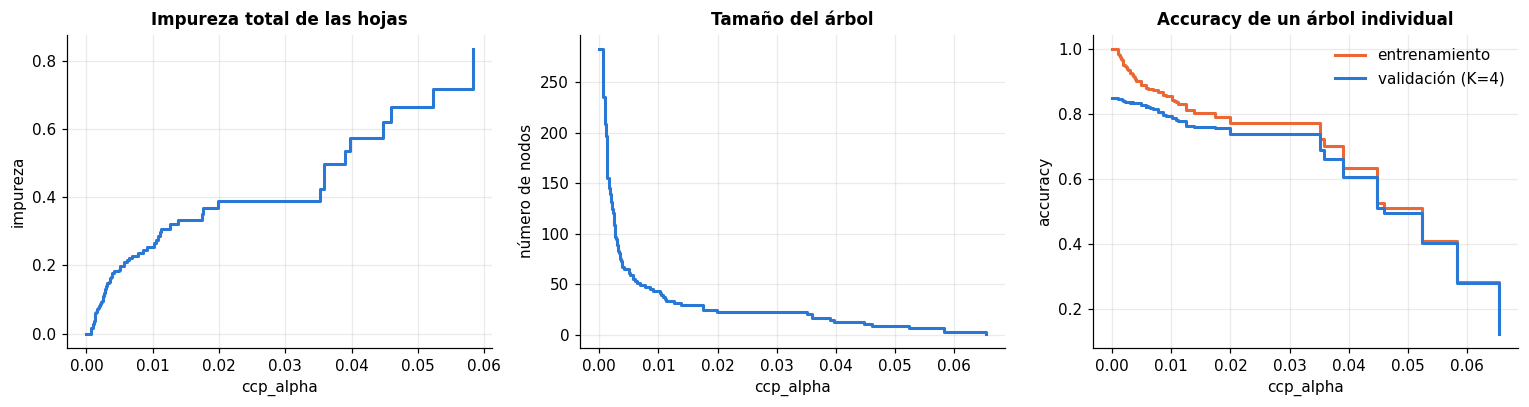

,ccp_alpha,nodos,profundidad,acc_train,acc_val
0,0.00000,283,14,1.0000,0.8497
10,0.00130,187,13,0.9770,0.8448
20,0.00159,151,10,0.9701,0.8476
40,0.00258,109,10,0.9397,0.8372
60,0.00389,69,10,0.9105,0.8337
70,0.00686,49,8,0.8731,0.8149
80,0.01382,29,7,0.8040,0.7606
85,0.03587,17,6,0.7003,0.6632


In [7]:
ruta = DecisionTreeClassifier(random_state=SEED).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurezas = ruta.ccp_alphas, ruta.impurities
alphas_ruta = np.unique(ccp_alphas)
print(f'La ruta de poda tiene {len(alphas_ruta)} valores distintos de alpha, entre {alphas_ruta.min():.4f} y {alphas_ruta.max():.4f}')

filas = []
for a in alphas_ruta:
    arbol = DecisionTreeClassifier(random_state=SEED, ccp_alpha=a).fit(X_train, y_train)
    r = cross_validate(DecisionTreeClassifier(random_state=SEED, ccp_alpha=a), X_train, y_train,
                       cv=kfold, return_train_score=True)
    filas.append({'ccp_alpha': a, 'nodos': arbol.tree_.node_count, 'profundidad': arbol.get_depth(),
                  'acc_train': r['train_score'].mean(), 'acc_val': r['test_score'].mean()})
arbol_ruta = pd.DataFrame(filas)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
axes[0].plot(ccp_alphas[:-1], impurezas[:-1], drawstyle='steps-post', color=AZUL)
axes[0].set(title='Impureza total de las hojas', xlabel='ccp_alpha', ylabel='impureza')
axes[1].plot(arbol_ruta['ccp_alpha'], arbol_ruta['nodos'], drawstyle='steps-post', color=AZUL)
axes[1].set(title='Tamaño del árbol', xlabel='ccp_alpha', ylabel='número de nodos')
axes[2].plot(arbol_ruta['ccp_alpha'], arbol_ruta['acc_train'], drawstyle='steps-post', color=NARANJA, label='entrenamiento')
axes[2].plot(arbol_ruta['ccp_alpha'], arbol_ruta['acc_val'], drawstyle='steps-post', color=AZUL, label='validación (K=4)')
axes[2].set(title='Accuracy de un árbol individual', xlabel='ccp_alpha', ylabel='accuracy')
axes[2].legend()
plt.tight_layout()
plt.show()

fmt(arbol_ruta.iloc[[0, 10, 20, 40, 60, 70, 80, 85]])

Con un árbol individual se ve la poda "clásica": al subir `ccp_alpha`, el árbol pasa de 283 nodos a unos pocos y la accuracy de entrenamiento
baja. Hasta $\alpha \approx 0.004$ la validación apenas cambia (de 85 % a 83 %) mientras la brecha con el entrenamiento se reduce de 15 a
~8 puntos: la poda elimina sobre todo ramas que solo memorizaban el entrenamiento. A partir de $\alpha \approx 0.01$ la validación cae
rápido (*underfitting*). Por eso se exploran los valores de la ruta con $\alpha \le 0.02$.

### 6.2 Valores candidatos de `ccp_alpha` para el bosque

Se toman **20 valores de la ruta** repartidos uniformemente (por posición) entre $0$ y $0.02$. Como la ruta es más densa en valores
pequeños, la exploración es más fina justo donde la poda empieza a actuar.

In [8]:
ALPHA_MAX = 0.02
cands = alphas_ruta[alphas_ruta <= ALPHA_MAX]
alphas = cands[np.unique(np.round(np.linspace(0, len(cands) - 1, 20)).astype(int))]
print(f'{len(alphas)} valores candidatos de ccp_alpha:')
print(np.round(alphas, 5))

20 valores candidatos de ccp_alpha:
[0.      0.00093 0.0013  0.00135 0.00138 0.00167 0.00191 0.00217 0.00244
 0.00253 0.00273 0.00295 0.00312 0.00359 0.00392 0.00568 0.00686 0.01021
 0.01255 0.01988]


## 7. Evaluación eficiente de bosques de 1 a 200 árboles

Para encontrar el **mínimo número de árboles** hay que evaluar muchos valores de `n_estimators`. En lugar de entrenar un bosque nuevo para
cada valor, se aprovechan dos propiedades de `RandomForestClassifier`:

1. Con el mismo `random_state`, los **primeros $n$ árboles** de un bosque de 200 son **exactamente** los árboles de un bosque con
   `n_estimators = n` (las semillas de los árboles se generan en secuencia). Es la misma idea de `warm_start`.
2. El bosque predice **promediando las probabilidades** de sus árboles.

Por tanto, basta con entrenar **un bosque de 200 árboles por fold**, acumular las probabilidades árbol por árbol y tomar la clase más probable,
y así se obtiene la accuracy de los bosques de 1, 2, …, 200 árboles en una sola pasada. La celda siguiente comprueba que el resultado es idéntico
al de entrenar cada bosque por separado.

In [9]:
def accuracy_acumulada(bosque, X, y):
    # Accuracy del bosque usando solo sus primeros 1, 2, ..., n árboles
    proba = np.cumsum([arbol.predict_proba(X) for arbol in bosque.estimators_], axis=0)  # (n_árboles, n_muestras, 10)
    pred = bosque.classes_[proba.argmax(axis=2)]                                         # (n_árboles, n_muestras)
    return (pred == y).mean(axis=1)                                                      # una accuracy por cada n


# Verificación en el primer fold
idx_tr, idx_va = next(kfold.split(X_train, y_train))
bosque = RandomForestClassifier(n_estimators=N_MAX, random_state=SEED, n_jobs=-1).fit(X_train[idx_tr], y_train[idx_tr])
curva = accuracy_acumulada(bosque, X_train[idx_va], y_train[idx_va])
for n in [1, 5, 25, 100]:
    directo = RandomForestClassifier(n_estimators=n, random_state=SEED, n_jobs=-1).fit(X_train[idx_tr], y_train[idx_tr])
    acc = directo.score(X_train[idx_va], y_train[idx_va])
    print(f'n = {n:3d} árboles | primeros n árboles del bosque de 200: {curva[n-1]:.4f} | '
          f'bosque entrenado con n_estimators={n}: {acc:.4f} | ¿iguales? {np.isclose(curva[n-1], acc)}')

n =   1 árboles | primeros n árboles del bosque de 200: 0.7917 | bosque entrenado con n_estimators=1: 0.7917 | ¿iguales? True
n =   5 árboles | primeros n árboles del bosque de 200: 0.8833 | bosque entrenado con n_estimators=5: 0.8833 | ¿iguales? True
n =  25 árboles | primeros n árboles del bosque de 200: 0.9667 | bosque entrenado con n_estimators=25: 0.9667 | ¿iguales? True
n = 100 árboles | primeros n árboles del bosque de 200: 0.9694 | bosque entrenado con n_estimators=100: 0.9694 | ¿iguales? True


## 8. Experimento principal: `ccp_alpha` × número de árboles con K-fold = 4

Para cada uno de los 20 valores de `ccp_alpha` y cada uno de los 4 folds se entrena un bosque de 200 árboles, y se guarda la accuracy de
**entrenamiento** y de **validación** de los bosques de 1 a 200 árboles. En total se evalúan 20 × 200 = 4 000 configuraciones,
cada una con K-fold = 4.

In [10]:
acc_tr = np.zeros((len(alphas), K, N_MAX))   # [alpha, fold, n_árboles - 1]
acc_va = np.zeros((len(alphas), K, N_MAX))
tam = []

t0 = time.time()
for i, alpha in enumerate(alphas):
    arboles = []
    for f, (idx_tr, idx_va) in enumerate(kfold.split(X_train, y_train)):
        bosque = RandomForestClassifier(n_estimators=N_MAX, ccp_alpha=alpha, random_state=SEED, n_jobs=-1)
        bosque.fit(X_train[idx_tr], y_train[idx_tr])
        acc_tr[i, f] = accuracy_acumulada(bosque, X_train[idx_tr], y_train[idx_tr])
        acc_va[i, f] = accuracy_acumulada(bosque, X_train[idx_va], y_train[idx_va])
        arboles += bosque.estimators_
    tam.append({'ccp_alpha': alpha, **tamano_arboles(arboles)})
tam = pd.DataFrame(tam)

print(f'{len(alphas)} alphas × {K} folds × {N_MAX} árboles, entrenados en {time.time() - t0:.0f} s')

20 alphas × 4 folds × 200 árboles, entrenados en 79 s


### 8.1 ¿Cómo cambia el desempeño con el número de árboles?

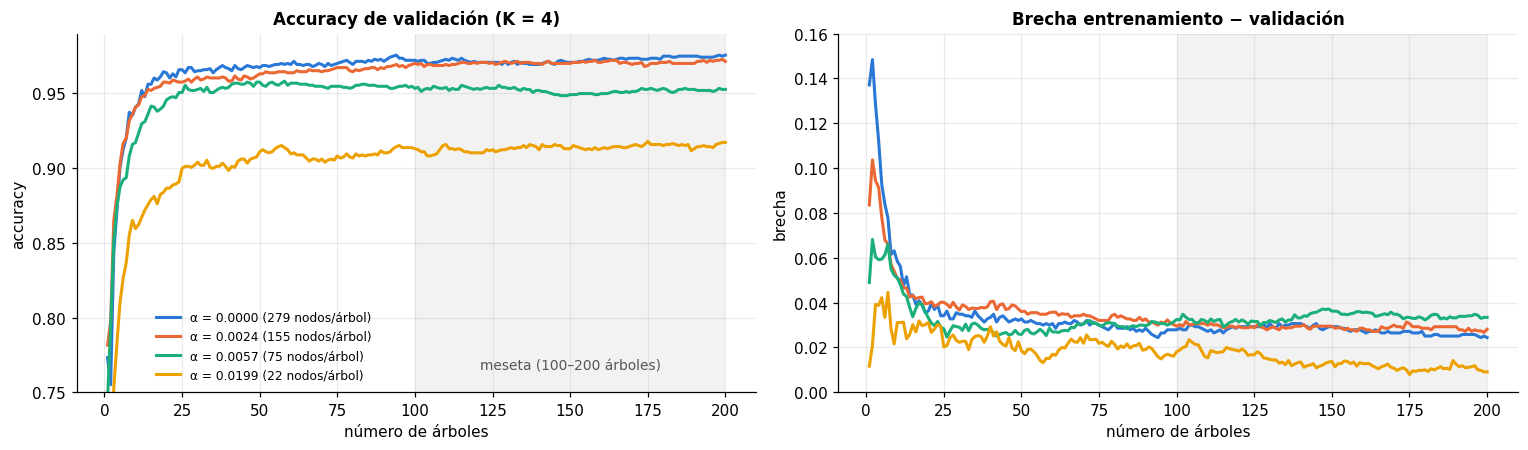

In [11]:
n = np.arange(1, N_MAX + 1)
representativos = [0, 8, 15, len(alphas) - 1]      # sin poda, poda leve, poda media y poda fuerte
colores = [AZUL, NARANJA, AQUA, AMARILLO]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
for i, c in zip(representativos, colores):
    etiqueta = f'α = {alphas[i]:.4f} ({tam.loc[i, "nodos/árbol"]:.0f} nodos/árbol)'
    va = acc_va[i].mean(axis=0)
    axes[0].plot(n, va, color=c, label=etiqueta)
    axes[1].plot(n, (acc_tr[i] - acc_va[i]).mean(axis=0), color=c, label=etiqueta)
for ax in axes:
    ax.axvspan(100, N_MAX, color=GRIS, alpha=0.10, lw=0)
axes[0].text(150, 0.765, 'meseta (100–200 árboles)', ha='center', fontsize=9, color='#555')
axes[0].set(title='Accuracy de validación (K = 4)', xlabel='número de árboles', ylabel='accuracy', ylim=(0.75, 0.99))
axes[1].set(title='Brecha entrenamiento − validación', xlabel='número de árboles', ylabel='brecha', ylim=(0, 0.16))
axes[0].legend(loc='lower left', bbox_to_anchor=(0.1, 0.0), fontsize=8)
plt.tight_layout()
plt.show()

**Observaciones.**

- Con cualquier nivel de poda, la accuracy de validación **sube rápido hasta ~50 árboles y se aplana a partir de ~100**. Entre 100 y 200 árboles
  el cambio es menor que la variación entre folds. Por eso se define la **meseta** como el rango de 100 a 200 árboles, y su promedio se usa
  como la accuracy "asintótica" de cada `ccp_alpha`.
- La brecha entrenamiento−validación depende sobre todo del **número de árboles**: con 1 o 2 árboles es de 8 a 15 puntos según la poda
  (over-fitting como el del árbol individual) y baja a ~3 puntos cuando el bosque es grande. Es decir, **con pocos árboles el bosque sobreajusta**,
  y eso fija el límite inferior del número de árboles.
- Una poda fuerte (α ≈ 0.02) reduce la brecha pero hunde la validación: es *underfitting*, no una mejora.

## 9. Selección del tamaño de los árboles (`ccp_alpha`)

**Regla de 1 error estándar** (Breiman et al., 1984, la misma regla con la que CART elige el nivel de poda):

1. Para cada α se calcula la accuracy de validación en la meseta y su error estándar entre los 4 folds, $\text{EE} = s / \sqrt{4}$.
2. Se identifica el α con la mayor accuracy.
3. Se elige **el α más grande** (árboles más pequeños) cuya accuracy esté a **no más de 1 EE** de la mejor. Diferencias menores que 1 EE no se
   distinguen del ruido de la validación cruzada, así que se prefiere el modelo más simple.

In [12]:
MESETA = slice(99, N_MAX)                                  # bosques de 100 a 200 árboles
meseta_fold = acc_va[:, :, MESETA].mean(axis=2)            # accuracy de la meseta en cada fold: [alpha, fold]

res = tam.copy()
res['acc_train'] = acc_tr[:, :, MESETA].mean(axis=(1, 2))
res['acc_val'] = meseta_fold.mean(axis=1)
res['EE'] = meseta_fold.std(axis=1, ddof=1) / np.sqrt(K)
res['brecha'] = res['acc_train'] - res['acc_val']

i_mejor = res['acc_val'].idxmax()
umbral_alpha = res.loc[i_mejor, 'acc_val'] - res.loc[i_mejor, 'EE']
res['cumple 1-EE'] = res['acc_val'] >= umbral_alpha
i_sel = res.index[res['cumple 1-EE']].max()                # alphas ordenados: el mayor que cumple
alpha_opt = alphas[i_sel]

print(f'Mejor accuracy de validación: {res.loc[i_mejor, "acc_val"]:.4f} (α = {alphas[i_mejor]:.5f}),  EE = {res.loc[i_mejor, "EE"]:.4f}')
print(f'Umbral (mejor − 1 EE): {umbral_alpha:.4f}')
print(f'α seleccionado: {alpha_opt:.5f}  ->  {res.loc[i_sel, "nodos/árbol"]:.1f} nodos/árbol, profundidad {res.loc[i_sel, "profundidad"]:.1f} '
      f'(sin poda: {res.loc[0, "nodos/árbol"]:.1f} nodos, profundidad {res.loc[0, "profundidad"]:.1f})')
fmt(res)

Mejor accuracy de validación: 0.9723 (α = 0.00000),  EE = 0.0021
Umbral (mejor − 1 EE): 0.9702
α seleccionado: 0.00244  ->  154.6 nodos/árbol, profundidad 10.9 (sin poda: 278.5 nodos, profundidad 12.9)


,ccp_alpha,nodos/árbol,hojas/árbol,profundidad,acc_train,acc_val,EE,brecha,cumple 1-EE
0,0.00000,278.5,139.8,12.9,1.0000,0.9723,0.0021,0.0277,True
1,0.00093,248.2,124.6,12.4,1.0000,0.9714,0.0025,0.0286,True
2,0.00130,229.1,115.1,12.1,1.0000,0.9712,0.0026,0.0288,True
3,0.00135,228.4,114.7,12.1,1.0000,0.9710,0.0025,0.0290,True
4,0.00138,228.0,114.5,12.1,1.0000,0.9710,0.0025,0.0290,True
5,0.00167,200.0,100.5,11.7,1.0000,0.9718,0.0026,0.0282,True
6,0.00191,171.4,86.2,11.3,0.9997,0.9715,0.0022,0.0281,True
7,0.00217,165.0,83.0,11.2,0.9995,0.9708,0.0021,0.0287,True
8,0.00244,154.6,77.8,10.9,0.9994,0.9704,0.0017,0.0289,True
9,0.00253,150.3,75.6,10.8,0.9993,0.9694,0.0021,0.0299,False


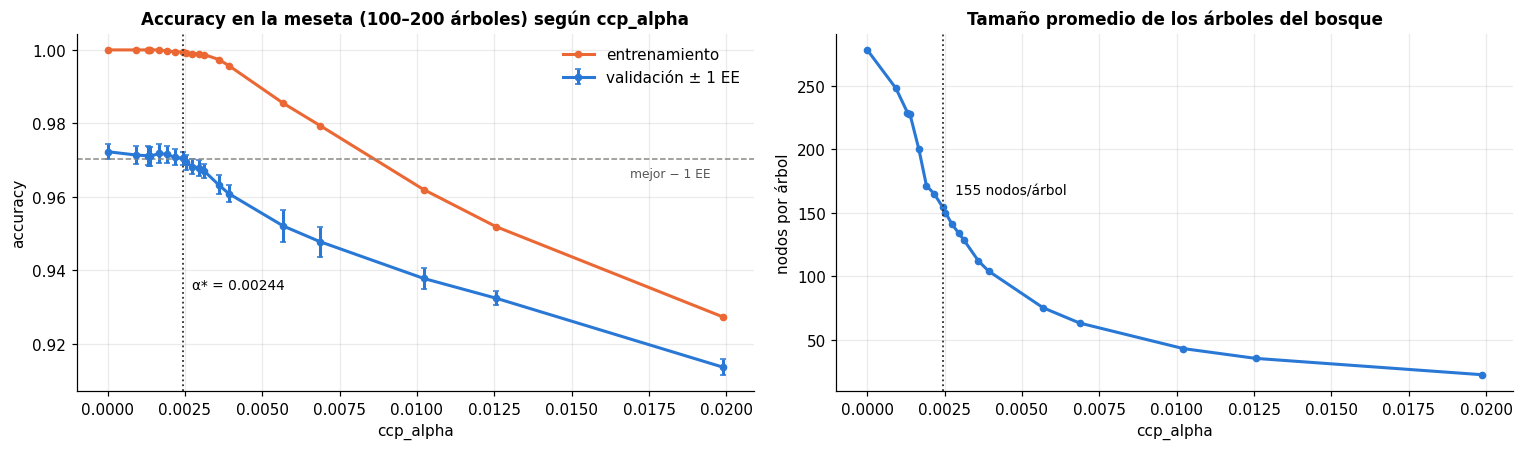

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), sharex=True)
ax = axes[0]
ax.plot(res['ccp_alpha'], res['acc_train'], 'o-', ms=4, color=NARANJA, label='entrenamiento')
ax.errorbar(res['ccp_alpha'], res['acc_val'], yerr=res['EE'], fmt='o-', ms=4, capsize=2, color=AZUL, label='validación ± 1 EE')
ax.axhline(umbral_alpha, color=GRIS, ls='--', lw=1)
ax.text(0.0195, umbral_alpha - 0.002, 'mejor − 1 EE', ha='right', va='top', fontsize=8, color='#555')
ax.set(title='Accuracy en la meseta (100–200 árboles) según ccp_alpha', xlabel='ccp_alpha', ylabel='accuracy')
ax.legend(loc='upper right')

ax = axes[1]
ax.plot(res['ccp_alpha'], res['nodos/árbol'], 'o-', ms=4, color=AZUL)
ax.set(title='Tamaño promedio de los árboles del bosque', xlabel='ccp_alpha', ylabel='nodos por árbol')
for ax in axes:
    ax.axvline(alpha_opt, color='#333', ls=':', lw=1.2)
axes[0].annotate(f'α* = {alpha_opt:.5f}', (alpha_opt, 0.935), xytext=(6, 0), textcoords='offset points', fontsize=9)
axes[1].annotate(f'{res.loc[i_sel, "nodos/árbol"]:.0f} nodos/árbol', (alpha_opt, res.loc[i_sel, 'nodos/árbol']),
                 xytext=(8, 8), textcoords='offset points', fontsize=9)
plt.tight_layout()
plt.show()

## 10. Selección del número de árboles

Con el α elegido, el **mínimo número de árboles** es el menor $n$ con el que la accuracy de validación entra en la meseta, es decir, llega a
no más de 1 EE de la accuracy de la meseta de ese α:

$$n^* = \min\{\,n : \text{acc}_{\text{val}}(n) \ge \text{acc}_{\text{meseta}}(\alpha^*) - \text{EE}(\alpha^*)\,\}$$

Con menos árboles, el bosque todavía no alcanzó su desempeño y la brecha con el entrenamiento es mayor (sobreajusta). Con más árboles, el
modelo crece sin mejorar de forma apreciable.

In [14]:
va = acc_va[i_sel].mean(axis=0)
tr = acc_tr[i_sel].mean(axis=0)
brecha = tr - va
umbral_n = res.loc[i_sel, 'acc_val'] - res.loc[i_sel, 'EE']
n_opt = int(np.argmax(va >= umbral_n) + 1)

print(f'Accuracy de la meseta con α* = {alpha_opt:.5f}: {res.loc[i_sel, "acc_val"]:.4f}   Umbral: {umbral_n:.4f}')
print(f'Mínimo número de árboles: n* = {n_opt}\n')
puntos = sorted(set([1, 5, 10, 25, 50, 75, n_opt, 100, 150, 200]))
fmt(pd.DataFrame({'n_árboles': puntos, 'acc_train': tr[np.array(puntos) - 1], 'acc_val': va[np.array(puntos) - 1],
                  'brecha': brecha[np.array(puntos) - 1]}).set_index('n_árboles'))

Accuracy de la meseta con α* = 0.00244: 0.9704   Umbral: 0.9688
Mínimo número de árboles: n* = 94



,acc_train,acc_val,brecha
n_árboles,,,
1,0.8650,0.7815,0.0835
5,0.9807,0.9026,0.0782
10,0.9916,0.9408,0.0508
25,0.9977,0.9575,0.0401
50,0.9991,0.9631,0.0360
75,0.9993,0.9673,0.0320
94,0.9993,0.9694,0.0299
100,0.9995,0.9701,0.0295
150,0.9995,0.9701,0.0295


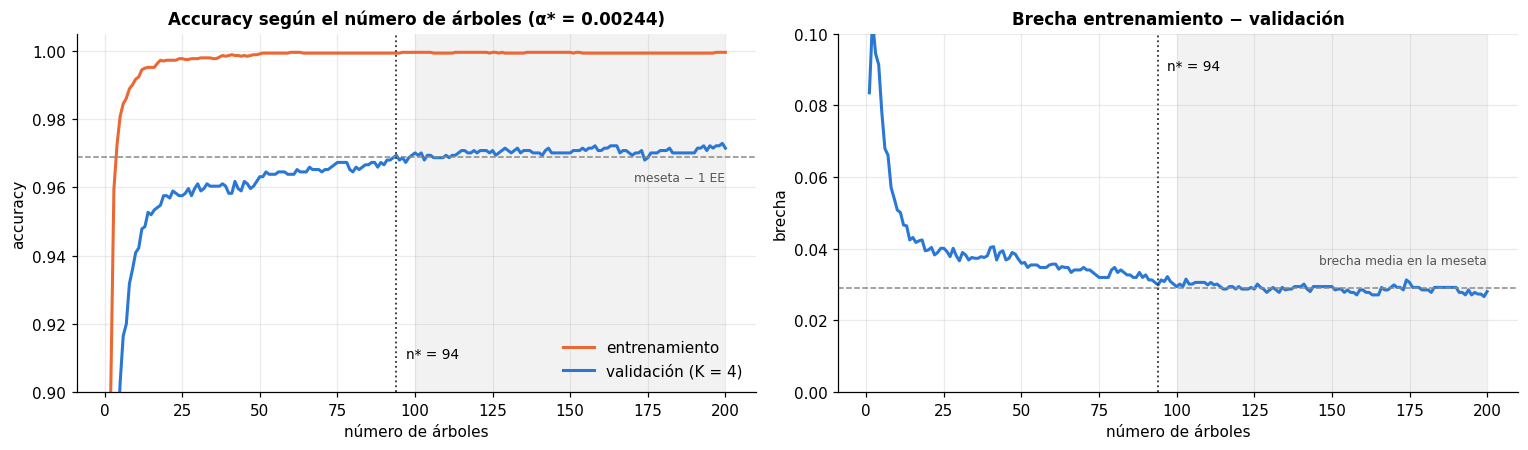

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
ax = axes[0]
ax.plot(n, tr, color=NARANJA, label='entrenamiento')
ax.plot(n, va, color=AZUL, label='validación (K = 4)')
ax.axhline(umbral_n, color=GRIS, ls='--', lw=1)
ax.text(N_MAX, umbral_n - 0.004, 'meseta − 1 EE', ha='right', va='top', fontsize=8, color='#555')
ax.set(title=f'Accuracy según el número de árboles (α* = {alpha_opt:.5f})', xlabel='número de árboles', ylabel='accuracy', ylim=(0.90, 1.005))
ax.legend(loc='lower right')

ax = axes[1]
ax.plot(n, brecha, color=AZUL)
ax.axhline(brecha[MESETA].mean(), color=GRIS, ls='--', lw=1)
ax.text(N_MAX, brecha[MESETA].mean() + 0.006, 'brecha media en la meseta', ha='right', va='bottom', fontsize=8, color='#555')
ax.set(title='Brecha entrenamiento − validación', xlabel='número de árboles', ylabel='brecha', ylim=(0, 0.10))
for ax in axes:
    ax.axvline(n_opt, color='#333', ls=':', lw=1.2)
    ax.axvspan(100, N_MAX, color=GRIS, alpha=0.10, lw=0)
axes[0].annotate(f'n* = {n_opt}', (n_opt, 0.91), xytext=(6, 0), textcoords='offset points', fontsize=9)
axes[1].annotate(f'n* = {n_opt}', (n_opt, 0.09), xytext=(6, 0), textcoords='offset points', fontsize=9)
plt.tight_layout()
plt.show()

### 10.1 Visión conjunta: accuracy de validación para cada combinación

El mapa muestra la accuracy de validación (K = 4, en %) para cada `ccp_alpha` y algunos números de árboles. El recuadro marca la configuración
elegida. Arriba a la izquierda (pocos árboles) el bosque todavía no converge; abajo (α grande) los árboles están demasiado podados.

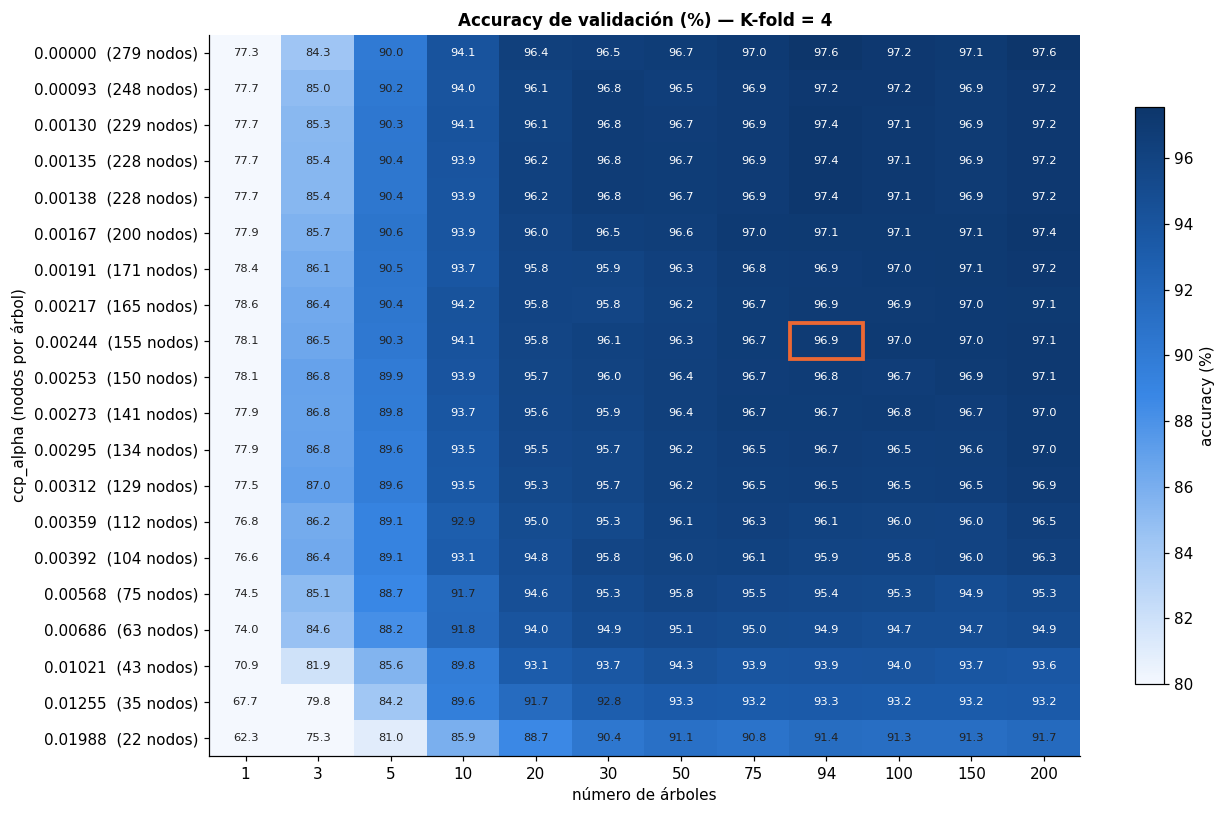

In [16]:
cols = sorted(set([1, 3, 5, 10, 20, 30, 50, 75, n_opt, 100, 150, 200]))
mapa = pd.DataFrame(acc_va[:, :, np.array(cols) - 1].mean(axis=1) * 100,
                    index=[f'{a:.5f}' for a in alphas], columns=cols)

fig, ax = plt.subplots(figsize=(12, 7.5))
im = ax.imshow(mapa.values, cmap=AZULES, aspect='auto', vmin=80, vmax=mapa.values.max())
for r in range(mapa.shape[0]):
    for c in range(mapa.shape[1]):
        v = mapa.values[r, c]
        ax.text(c, r, f'{v:.1f}', ha='center', va='center', fontsize=7.5, color='white' if v > 93 else '#222')
ax.set_xticks(range(len(cols)), cols)
ax.set_yticks(range(len(alphas)), [f'{a:.5f}  ({tam.loc[i, "nodos/árbol"]:.0f} nodos)' for i, a in enumerate(alphas)])
ax.set(xlabel='número de árboles', ylabel='ccp_alpha (nodos por árbol)', title='Accuracy de validación (%) — K-fold = 4')
ax.grid(False)
ax.add_patch(Rectangle((cols.index(n_opt) - 0.5, i_sel - 0.5), 1, 1, fill=False, ec=NARANJA, lw=2.5))
fig.colorbar(im, ax=ax, shrink=0.8, label='accuracy (%)')
plt.tight_layout()
plt.show()

## 11. ¿Poda posterior (`ccp_alpha`) o poda previa (`max_depth`, `min_samples_leaf`)?

Para justificar la estrategia, se comparan las tres formas de limitar el tamaño de los árboles en bosques de $n^*$ árboles, con el mismo K-fold = 4.
Lo que interesa es qué estrategia da **mejor accuracy para un mismo tamaño de árbol**.

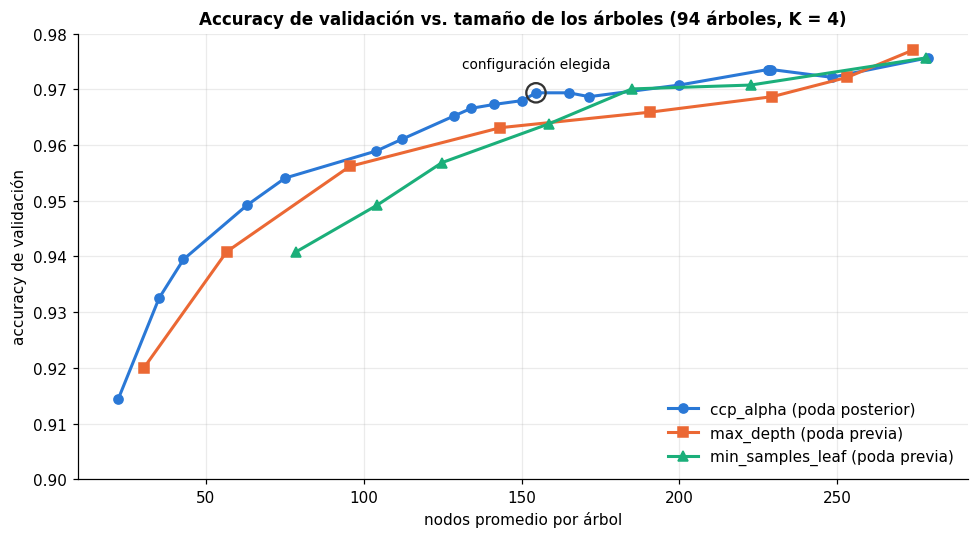

,nodos/árbol,profundidad,acc_train,acc_val,brecha
modelo,,,,,
max_depth=4,30.4,4.0,0.9483,0.9200,0.0283
max_depth=5,56.7,5.0,0.9733,0.9409,0.0325
max_depth=6,95.6,6.0,0.9910,0.9562,0.0348
max_depth=7,143.3,7.0,0.9979,0.9631,0.0348
max_depth=8,190.6,8.0,0.9993,0.9659,0.0334
max_depth=9,229.3,9.0,1.0000,0.9687,0.0313
max_depth=10,253.1,10.0,1.0000,0.9722,0.0278
max_depth=12,273.9,11.9,1.0000,0.9770,0.0230
min_samples_leaf=1,278.0,13.0,1.0000,0.9756,0.0244


In [17]:
filas = []
for d in [4, 5, 6, 7, 8, 9, 10, 12]:
    f = evaluar_cv(RandomForestClassifier(n_estimators=n_opt, max_depth=d, random_state=SEED, n_jobs=-1), f'max_depth={d}')
    filas.append({'estrategia': 'max_depth (poda previa)', **f})
for m in [1, 2, 3, 4, 6, 8, 12]:
    f = evaluar_cv(RandomForestClassifier(n_estimators=n_opt, min_samples_leaf=m, random_state=SEED, n_jobs=-1), f'min_samples_leaf={m}')
    filas.append({'estrategia': 'min_samples_leaf (poda previa)', **f})
comp = pd.DataFrame(filas)

# Para ccp_alpha se reutilizan los resultados del experimento principal con n* árboles
ccp = pd.DataFrame({'estrategia': 'ccp_alpha (poda posterior)', 'nodos/árbol': tam['nodos/árbol'],
                    'acc_val': acc_va[:, :, n_opt - 1].mean(axis=1)})

fig, ax = plt.subplots(figsize=(9, 5))
for (nombre, datos), c, mk in zip([('ccp_alpha (poda posterior)', ccp),
                                   ('max_depth (poda previa)', comp[comp.estrategia.str.startswith('max_depth')]),
                                   ('min_samples_leaf (poda previa)', comp[comp.estrategia.str.startswith('min_samples')])],
                                  [AZUL, NARANJA, AQUA], ['o', 's', '^']):
    datos = datos.sort_values('nodos/árbol')
    ax.plot(datos['nodos/árbol'], datos['acc_val'], marker=mk, ms=6, color=c, label=nombre)
ax.scatter([tam.loc[i_sel, 'nodos/árbol']], [acc_va[i_sel, :, n_opt - 1].mean()], s=160, facecolors='none',
           edgecolors='#333', lw=1.5, zorder=5)
ax.annotate('configuración elegida', (tam.loc[i_sel, 'nodos/árbol'], acc_va[i_sel, :, n_opt - 1].mean()),
            xytext=(0, 14), textcoords='offset points', ha='center', va='bottom', fontsize=9)
ax.set(title=f'Accuracy de validación vs. tamaño de los árboles ({n_opt} árboles, K = 4)',
       xlabel='nodos promedio por árbol', ylabel='accuracy de validación', ylim=(0.90, 0.98))
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

fmt(comp[['modelo', 'nodos/árbol', 'profundidad', 'acc_train', 'acc_val', 'brecha']].set_index('modelo'))

**Resultado de la comparación.**

- **Con árboles del mismo tamaño, `ccp_alpha` da mayor accuracy.** Con ~150 nodos por árbol, la poda posterior logra 96.9 %, frente a 96.3 %
  de `max_depth = 7` (143 nodos) y 96.4 % de `min_samples_leaf = 4` (159 nodos). Con árboles pequeños (40–100 nodos), `ccp_alpha` queda igual o
  por encima de `max_depth` y alrededor de 1 punto por encima de `min_samples_leaf`.
- **También sobreajusta menos a igual tamaño.** La brecha es de 3.0 puntos con `ccp_alpha`, frente a 3.5 y 3.4 puntos con `max_depth = 7` y
  `min_samples_leaf = 4`.
- Con árboles grandes (> 250 nodos) las tres estrategias equivalen a no podar y sus diferencias quedan dentro del ruido de la validación cruzada.

La razón es la que se anticipó en la sección 6: `max_depth` corta todas las ramas a la misma profundidad, aunque algunas necesiten más niveles
para separar dígitos parecidos (8 vs. 1, 9 vs. 3), mientras que `ccp_alpha` conserva las ramas que reducen bastante la impureza y elimina las que no.

## 12. Configuración seleccionada frente a la línea base (validación cruzada)

Se vuelve a evaluar la configuración elegida con `cross_validate` (sin el atajo de los bosques anidados) para confirmar los números y compararla
con el Random Forest por defecto.

In [18]:
seleccion = evaluar_cv(RandomForestClassifier(n_estimators=n_opt, ccp_alpha=alpha_opt, random_state=SEED, n_jobs=-1),
                       f'Random Forest seleccionado ({n_opt} árboles, α = {alpha_opt:.5f})')
resumen = pd.concat([base, pd.DataFrame([seleccion]).set_index('modelo')])
display(fmt(resumen))

rf_def, rf_sel = resumen.iloc[1], resumen.iloc[2]
print(f'Reducción del tamaño de cada árbol: {1 - rf_sel["nodos/árbol"] / rf_def["nodos/árbol"]:.1%} de los nodos '
      f'({rf_def["profundidad"]:.1f} -> {rf_sel["profundidad"]:.1f} niveles)')
print(f'Reducción del tamaño total del bosque: {1 - rf_sel["nodos totales"] / rf_def["nodos totales"]:.1%} de los nodos')
print(f'Cambio en accuracy de validación: {rf_sel["acc_val"] - rf_def["acc_val"]:+.4f}')

,n_árboles,ccp_alpha,nodos/árbol,hojas/árbol,profundidad,nodos totales,acc_train,acc_val,f1_val,brecha
modelo,,,,,,,,,,
Árbol de decisión sin podar,1,0.00000,227.5,114.2,13.0,228.0,1.0000,0.8497,0.8487,0.1503
Random Forest por defecto (100 árboles),100,0.00000,277.7,139.4,13.0,27771.0,1.0000,0.9722,0.9719,0.0278
"Random Forest seleccionado (94 árboles, α = 0.00244)",94,0.00244,154.1,77.5,11.0,14485.0,0.9993,0.9694,0.9691,0.0299


Reducción del tamaño de cada árbol: 44.5% de los nodos (13.0 -> 11.0 niveles)
Reducción del tamaño total del bosque: 47.8% de los nodos
Cambio en accuracy de validación: -0.0028


## 13. Evaluación final sobre el conjunto de prueba (20 %)

Ahora sí se usa el conjunto de prueba, **una sola vez**. El modelo final se entrena con todo el 80 % de entrenamiento. Se activa además
`oob_score=True`: cada árbol no ve ~37 % de las muestras (las que quedaron fuera de su muestra *bootstrap*), y con ellas el bosque calcula
una estimación adicional del error de generalización (*out-of-bag*).

In [19]:
rf_final = RandomForestClassifier(n_estimators=n_opt, ccp_alpha=alpha_opt, oob_score=True,
                                  random_state=SEED, n_jobs=-1).fit(X_train, y_train)
rf_defecto = RandomForestClassifier(random_state=SEED, n_jobs=-1).fit(X_train, y_train)
arbol_solo = DecisionTreeClassifier(random_state=SEED).fit(X_train, y_train)


def metricas_prueba(modelo, nombre):
    y_pred = modelo.predict(X_test)
    arboles = modelo.estimators_ if hasattr(modelo, 'estimators_') else [modelo]
    fila = {'modelo': nombre, 'n_árboles': len(arboles), **tamano_arboles(arboles)}
    fila['nodos totales'] = len(arboles) * fila['nodos/árbol']
    fila.update({'acc_train': modelo.score(X_train, y_train),
            'acc_test': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred, average='macro'),
            'recall': recall_score(y_test, y_pred, average='macro'),
            'f1': f1_score(y_test, y_pred, average='macro')})
    fila['brecha train-test'] = fila['acc_train'] - fila['acc_test']
    return fila


prueba = pd.DataFrame([
    metricas_prueba(arbol_solo, 'Árbol de decisión sin podar'),
    metricas_prueba(rf_defecto, 'Random Forest por defecto (100 árboles)'),
    metricas_prueba(rf_final, f'Random Forest seleccionado ({n_opt} árboles, α = {alpha_opt:.5f})'),
]).set_index('modelo')
fmt(prueba)

,n_árboles,nodos/árbol,hojas/árbol,profundidad,nodos totales,acc_train,acc_test,precision,recall,f1,brecha train-test
modelo,,,,,,,,,,,
Árbol de decisión sin podar,1,283.0,142.0,14.0,283.0,1.0000,0.8250,0.8236,0.8242,0.8230,0.1750
Random Forest por defecto (100 árboles),100,340.0,170.5,13.3,34002.0,1.0000,0.9611,0.9620,0.9607,0.9607,0.0389
"Random Forest seleccionado (94 árboles, α = 0.00244)",94,153.3,77.1,10.8,14410.0,0.9986,0.9611,0.9620,0.9607,0.9607,0.0375


In [20]:
acc_cv = seleccion['acc_val']
acc_oob = rf_final.oob_score_
acc_test = prueba.iloc[2]['acc_test']
ee_test = np.sqrt(acc_test * (1 - acc_test) / len(y_test))   # error estándar de una proporción con 360 muestras

print('Tres estimaciones independientes del desempeño del modelo seleccionado:')
print(f'  Validación cruzada (K = 4): {acc_cv:.4f}')
print(f'  Out-of-bag (OOB):           {acc_oob:.4f}')
print(f'  Conjunto de prueba (20 %):  {acc_test:.4f}  (± {ee_test:.4f} de error estándar con {len(y_test)} imágenes)')
print(f'\nDiferencia prueba − validación cruzada: {acc_test - acc_cv:+.4f}')

Tres estimaciones independientes del desempeño del modelo seleccionado:
  Validación cruzada (K = 4): 0.9694
  Out-of-bag (OOB):           0.9589
  Conjunto de prueba (20 %):  0.9611  (± 0.0102 de error estándar con 360 imágenes)

Diferencia prueba − validación cruzada: -0.0083


**Verificación de over-fitting en prueba.**

- La accuracy en prueba (96.1 %) está a menos de 1 punto de la de validación cruzada (96.9 %). Esa diferencia es menor que el error estándar
  de la propia medición en prueba (±1.0 punto con 360 imágenes, es decir, unas 4 imágenes), así que ambas estimaciones son consistentes.
- El bosque seleccionado obtiene **exactamente la misma accuracy, precisión, recall y F1 en prueba que el Random Forest por defecto**, con
  6 árboles menos y árboles de menos de la mitad de nodos (en total ~58 % menos nodos).
- La brecha entrenamiento−prueba (3.7 puntos) es similar a la del bosque por defecto (3.9) y muy inferior a la del árbol individual (17.5 puntos).
- La estimación *out-of-bag* es algo más baja (95.9 %) porque cada imagen se predice solo con los ~35 árboles que no la vieron (≈ 37 % de 94),
  y la curva de la sección 10 muestra que un bosque de ~35 árboles valida alrededor de 96 %. Por eso es una estimación algo pesimista.

              precision    recall  f1-score   support

           0     0.9722    0.9722    0.9722        36
           1     0.8974    0.9722    0.9333        36
           2     1.0000    0.9714    0.9855        35
           3     0.9730    0.9730    0.9730        37
           4     0.9722    0.9722    0.9722        36
           5     0.9737    1.0000    0.9867        37
           6     1.0000    0.9722    0.9859        36
           7     0.9231    1.0000    0.9600        36
           8     0.9375    0.8571    0.8955        35
           9     0.9706    0.9167    0.9429        36

    accuracy                         0.9611       360
   macro avg     0.9620    0.9607    0.9607       360
weighted avg     0.9620    0.9611    0.9609       360



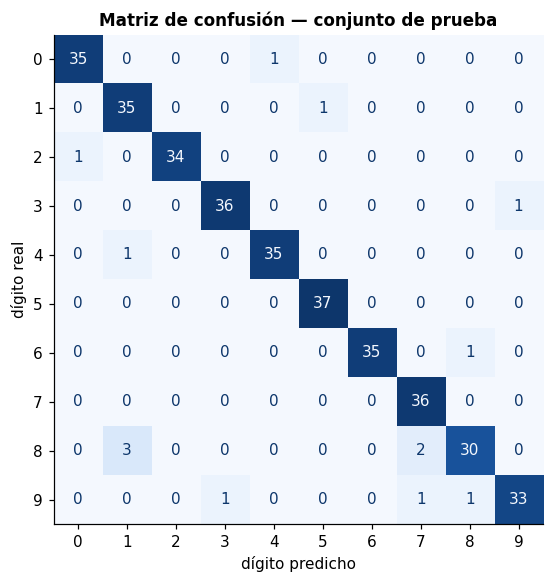

In [21]:
y_pred = rf_final.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))

fig, ax = plt.subplots(figsize=(6.2, 5.4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap=AZULES, colorbar=False, ax=ax)
ax.set(title='Matriz de confusión — conjunto de prueba', xlabel='dígito predicho', ylabel='dígito real')
ax.grid(False)
plt.tight_layout()
plt.show()

## 14. Inspección del modelo final

### 14.1 Uno de los árboles podados del bosque (primeros 3 niveles)

Árbol 1 de 94: 143 nodos, 72 hojas, profundidad 12


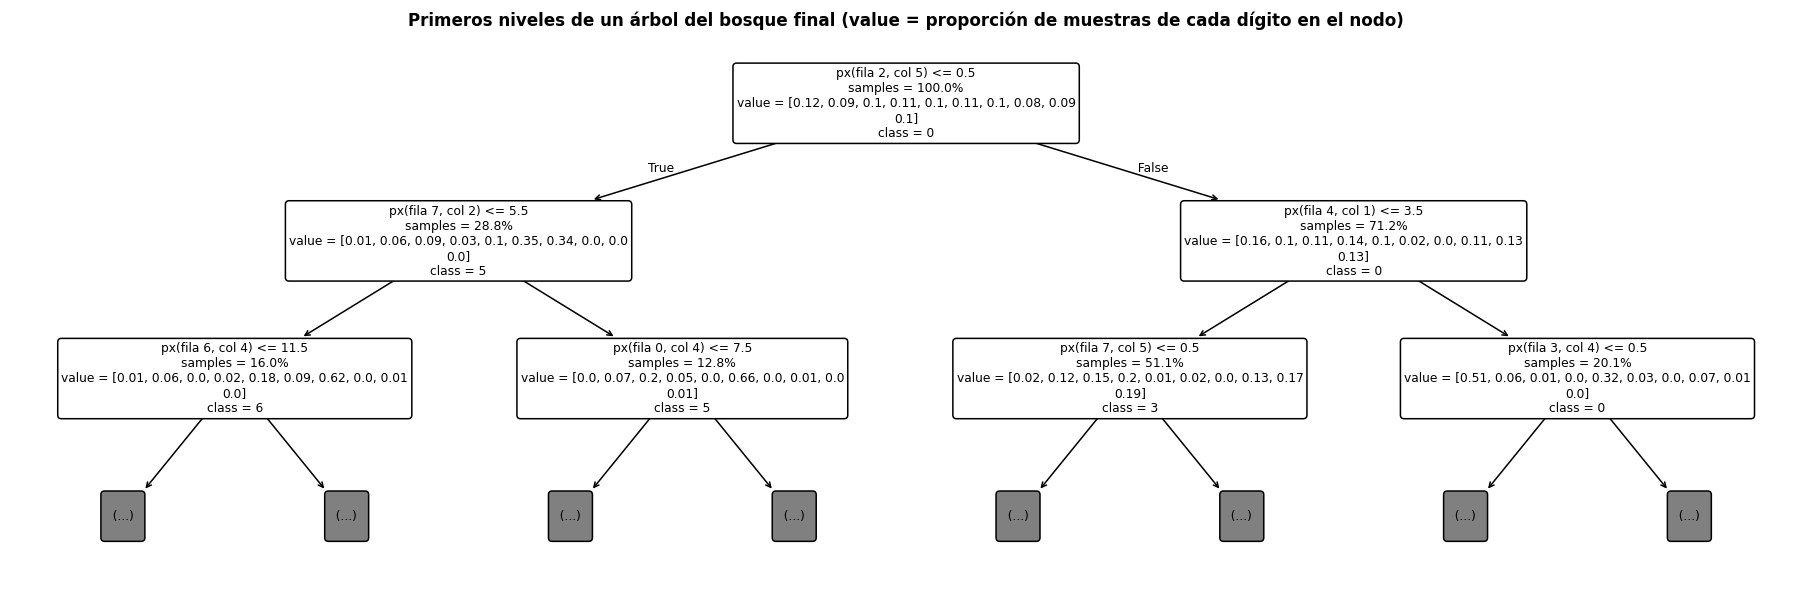

In [22]:
arbol0 = rf_final.estimators_[0]
print(f'Árbol 1 de {n_opt}: {arbol0.tree_.node_count} nodos, {arbol0.get_n_leaves()} hojas, profundidad {arbol0.get_depth()}')
nombres = [f'px(fila {i // 8}, col {i % 8})' for i in range(64)]

fig, ax = plt.subplots(figsize=(21, 6.5))
plot_tree(arbol0, max_depth=2, feature_names=nombres, class_names=[str(c) for c in range(10)],
          impurity=False, proportion=True, precision=2, rounded=True, fontsize=8, ax=ax)
ax.set_title('Primeros niveles de un árbol del bosque final (value = proporción de muestras de cada dígito en el nodo)')
plt.show()

### 14.2 Imágenes de prueba mal clasificadas

14 errores de 360 imágenes de prueba


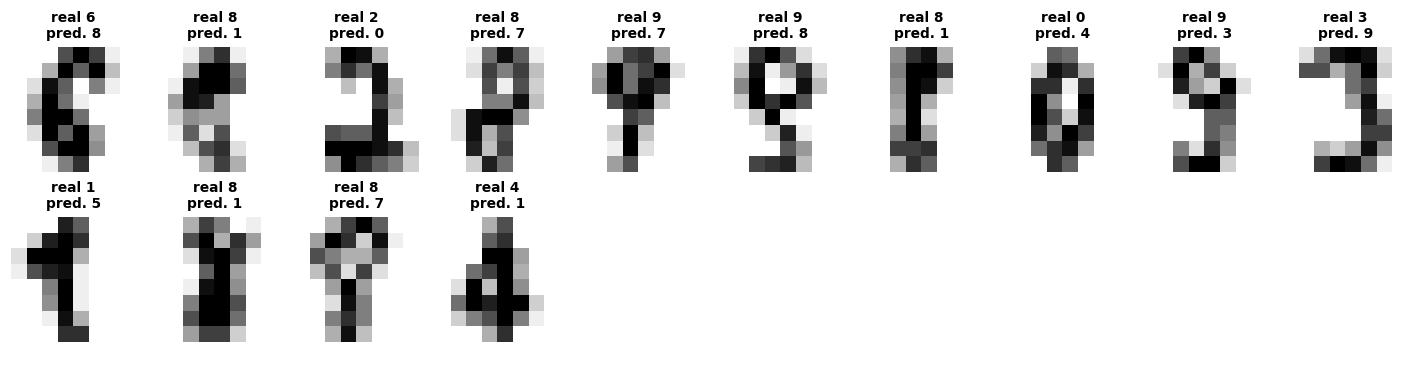

In [24]:
errores = np.where(y_pred != y_test)[0]
print(f'{len(errores)} errores de {len(y_test)} imágenes de prueba')

cols_fig = min(len(errores), 10)
filas_fig = int(np.ceil(len(errores) / cols_fig))
fig, axes = plt.subplots(filas_fig, cols_fig, figsize=(1.3 * cols_fig, 1.7 * filas_fig), squeeze=False)
for ax in axes.ravel():
    ax.axis('off')
for ax, i in zip(axes.ravel(), errores):
    ax.imshow(X_test[i].reshape(8, 8), cmap='gray_r')
    ax.set_title(f'real {y_test[i]}\npred. {y_pred[i]}', fontsize=9)
plt.tight_layout()
plt.show()

## 15. Conclusiones

**1. Configuración encontrada.** El mínimo número de árboles, del menor tamaño posible, que da los mejores indicadores sin over-fitting es:

| Parámetro | Valor |
|---|---|
| `n_estimators` | **94 árboles** |
| `ccp_alpha` | **0.00244** |
| Tamaño promedio por árbol | (78 hojas), profundidad ~11 |
| Accuracy / F1 en validación cruzada (K = 4) | 96.9 % / 96.9 % |
| Accuracy / precisión / recall / F1 en prueba | 96.1 % / 96.2 % / 96.1 % / 96.1 % |

Frente al Random Forest por defecto (100 árboles sin podar), cada árbol tiene **~45 % menos nodos** y el bosque completo **48–58 % menos nodos**. El desempeño en prueba es idéntico y en validación cruzada la diferencia es de
0.3 puntos, del orden de 1 error estándar (≈ 1 imagen por fold).

**2. Estrategia de poda.** Se usó **poda posterior por costo-complejidad** (`ccp_alpha`). Cada árbol del bosque crece completo sobre su muestra
*bootstrap* y luego se eliminan las ramas cuyo aporte a la reducción de impureza no compensa el costo $\alpha$ por hoja. Los valores de α se
tomaron de la ruta de poda (`cost_complexity_pruning_path`) y se eligió el **mayor α cuya accuracy de validación está a menos de 1 error estándar
de la mejor** (regla de 1 EE). Un α mayor ya reduce la accuracy más allá del ruido (*underfitting*). Frente a la poda previa (`max_depth`,
`min_samples_leaf`), `ccp_alpha` logra mayor accuracy y menor brecha con árboles del mismo tamaño.

**3. Número de árboles y over-fitting.** Con pocos árboles el bosque sobreajusta: con 1–2 árboles la brecha entrenamiento−validación es de 8 a
15 puntos, como la de un árbol individual. Al agregar árboles la brecha baja y se estabiliza en ~3 puntos, y la validación llega a su meseta.
**94 árboles** es el menor número con el que la validación alcanza la meseta (a menos de 1 EE). Con 50 árboles, por ejemplo, todavía se pierden
~0.7 puntos y la brecha sigue bajando. La ausencia de over-fitting se confirma porque la brecha ya es la de la meseta y porque el desempeño en
prueba coincide con el de validación cruzada dentro de su margen de error.

**4. Lección principal.** En un Random Forest, **los dos parámetros controlan cosas distintas**. El número de árboles controla la varianza, es
decir, el over-fitting: promediar árboles cierra la brecha. La poda controla el tamaño y el costo del modelo. A diferencia de un árbol
individual, la poda no mejora la accuracy del bosque, porque el promedio ya regulariza, pero permite **árboles casi la mitad de grandes sin
pérdida medible**.

**5. Errores.** De las 360 imágenes de prueba se clasificaron mal 14. La mayoría son 8 confundidos con 1 o 7 y 9 confundidos con 3, 7 u 8:
dígitos con trazos parecidos a 8×8 píxeles.

## Referencias
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2.ª ed.), secciones 7.10 (validación cruzada y regla de 1 EE) y 15 (Random Forests). Springer.
- Scikit-learn: [Post pruning decision trees with cost complexity pruning](https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html) y documentación de [`RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html).
- Zurek, E. Cuaderno [`ccp_alpha` en `DecisionTreeClassifier`](https://github.com/eduardozurek/ia/blob/main/_007_aprendizaje_supervisado/_007_arboles_de_decision/_007_01_ccp_alpha_DecisionTreeClassifier.ipynb).